# Research Intake 2026 — Day 29
# Introduction to CNNs

**Module:** Computer Vision Fundamentals
**Source:** Gudsky Research Foundation — Research Intake 2026, Day 29

This notebook accompanies the Day 29 reading and translates its theoretical content into a hands-on,
runnable format: the convolution operation from first principles, layer mechanics, pooling,
activations, a complete LeNet-style architecture, the full training loop, regularization, and
CNN interpretability (filter visualization, feature maps, Grad-CAM).

**Note on this day's structure:** Day 29 is a theory-consolidation day with no assigned practical
project brief, per the source document. This notebook front-loads runnable demonstrations of every
mechanism as it is introduced, and closes with the day's own debugging checklist and glossary rather
than a project assignment.

**How to use this notebook:** each section opens with a markdown summary of the corresponding reading
section, followed by a code cell demonstrating the concept directly — mostly using NumPy for the
from-first-principles mechanics (Sections 2–5) and PyTorch once a full trainable architecture is
assembled (Sections 6 onward).


## Audit Note — Issues Found and Resolved in This Revision

This notebook was checked against its source PDF (*Research Intake 2026, Day 29*) by (1)
independently recomputing every worked example and (2) executing every NumPy-only code cell
directly. Three issues surfaced; all three are fixed in this revision.

| # | Issue | Where | Fix |
|---|---|---|---|
| 1 | `torch.manual_seed(0)` sat **outside** the `try/except ImportError` block. If PyTorch were missing, the graceful "not installed" message printed, then the very next line crashed with `NameError: name 'torch' is not defined`. | §0 Environment Setup | Both seed calls now run inside an `HAS_TORCH` guard; the notebook degrades gracefully (NumPy sections still run) instead of crashing at cell 1. |
| 2 | `SimpleCNN`'s classifier implemented only **two** FC layers (`400→120`, `120→num_classes`), but the adjacent "total parameter count" worked example — and the source PDF's own Figure 7 — assume the classic LeNet-5 **three**-layer template (`400→120→84→10`). The model and its own worked example disagreed. | §6 Building a CNN Architecture | Added the missing 84-unit FC layer so `SimpleCNN` matches Figure 7 exactly. The parameter-count cell now asserts the live model's count equals the worked example's 62,006 — verified below. |
| 3 | Source PDF states `0.045⁷ ≈ 3×10⁻¹¹` in the vanishing-gradient worked example. Independent computation (both by hand and via this notebook's own code) gives **≈3.8×10⁻¹⁰** — about 12× larger, an order-of-magnitude arithmetic slip in the source document. | §5.2 ReLU and Its Dominance | The notebook never hardcoded the source's figure (it only computes the value live), so it was already numerically correct. A note is added at the point of computation so the discrepancy is documented rather than silently passed over. |

No other issues were found: all remaining worked-example arithmetic (output-size formula, receptive
field growth, multi-channel/1×1-conv parameter counts, dilation, pooling compute savings, GAP
reduction, depthwise-separable cost comparison, cross-entropy values) was independently re-executed
and matches both this notebook's output and the source PDF exactly.


## 0. Environment Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

HAS_TORCH = False
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    print("PyTorch version:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    HAS_TORCH = True
except ImportError:
    print("PyTorch not installed — install with: pip install torch")
    print("Sections 2-5 (NumPy-only) will still run; Sections 6-10 require PyTorch.")

np.random.seed(0)
if HAS_TORCH:
    torch.manual_seed(0)


PyTorch version: 2.11.0+cu128
CUDA available: True


## 1. From Handcrafted Features to Learned Features

This day marks the module's central turning point. Days 26–28 developed the classical CV pipeline
entirely from hand-designed algorithms. Day 28 closed with a direct forward reference here: once a
neural network can learn a better keypoint detector/descriptor than any hand-designed one, the natural
question is *how such a network actually works*. This day answers that from first principles.

### 1.1 Day 28's closing thread — SIFT/ORB/HOG as handcrafted invariances
In every classical case (SIFT's gradient histograms, ORB's pixel-pair comparisons, HOG's sliding-window
histograms), a human researcher decided *in advance* which mathematical operations would produce a
useful representation. What changes in the deep learning era is entirely **how the extraction stage's
parameters are determined**: fixed by a human (classical) vs. discovered by gradient descent (deep
learning) — the general pipeline shape ("extract structure, then use it") stays the same.

### 1.2 The 2012 AlexNet moment — a recap
AlexNet reduced ImageNet top-5 error from ≈26% (best classical approach) to ≈15% — a step-change large
enough to redirect the field's research effort entirely.

### 1.3 Why this shift happened — data, compute, and architecture

| Ingredient | What Changed by 2012 | Covered In |
|---|---|---|
| Data | ImageNet: 14M+ labelled images, 20,000+ categories | Day 26 §1.1 |
| Compute | GPUs repurposed for general-purpose parallel computation | Day 26 §1.1 |
| Training tricks | ReLU activations, dropout regularization | §5.2, §8.2 (this day) |
| Architecture | Deep stacks of learned convolutional filters | §2–§6 (this day) |

**Side-by-side: a hand-designed filter vs. a learned one.** A Sobel kernel (Day 26 §5.1) is a fixed
3×3 matrix, chosen by a human to approximate a gradient — its nine weights never change. A single
learned convolutional filter starts as random noise and is updated by gradient descent until its
weights minimize a training loss — and empirically, many early-layer learned filters end up looking
remarkably similar to Sobel-style edge detectors anyway (revisited directly in §9.1).

| Year | Milestone | Significance |
|---|---|---|
| 1989 | LeNet (LeCun) | Conceptually similar architecture, over 20 years before its breakthrough moment |
| 2012 | AlexNet | ImageNet breakthrough (§1.2) |
| 2014 | Dropout published | Regularization enabling deeper, less overfit networks (§8.2) |
| 2015 | Batch normalization published | Training-stability technique enabling faster, deeper training (§8.3) |


## 2. The Convolution Operation

### 2.1 Convolution as a sliding-window weighted sum
Mechanically identical to the filtering operations already covered (Day 26 §5, Day 27 §4): a small
kernel slides across the input, multiplying element-wise against the values underneath it and summing
the results to produce one output value per position.


In [2]:
# Worked Example: computing one convolution output value by hand (mirrors the reading's example)
patch = np.array([[1, 2, 0],
                   [0, 1, 2],
                   [1, 0, 1]])
kernel = np.array([[1, 0, -1],
                    [1, 0, -1],
                    [1, 0, -1]])

output_value = np.sum(patch * kernel)
print("Element-wise product:\n", patch * kernel)
print("Sum (this becomes one output pixel):", output_value)


Element-wise product:
 [[ 1  0  0]
 [ 0  0 -2]
 [ 1  0 -1]]
Sum (this becomes one output pixel): -1


In [3]:
# Full sliding-window convolution over a 5x5 input with a 3x3 kernel, from scratch (no library calls)
def convolve2d(input_arr, kernel_arr, stride=1, padding=0):
    """Cross-correlate a 2D kernel across a 2D input (§2.1-2.2: this is technically
    cross-correlation, not flipped mathematical convolution -- the deep-learning
    convention this notebook follows throughout).

    Parameters
    ----------
    input_arr : np.ndarray, shape (H, W)
        The input feature map / image to convolve.
    kernel_arr : np.ndarray, shape (kh, kw)
        The filter weights. In a real CNN these are learned (§2.3); here they are
        fixed so the sliding-window mechanics can be inspected directly.
    stride : int, default 1
        How many positions the kernel moves between applications (§3.1). stride=1
        moves one pixel at a time; stride=2 skips every other position, roughly
        halving each output spatial dimension.
    padding : int, default 0
        Number of zero-pixels added to each side of the input before convolving
        (§3.2). padding=0 is "valid" convolution (output shrinks by kernel_size-1);
        a nonzero value is how "same" padding is constructed.

    Returns
    -------
    np.ndarray, shape (out_h, out_w)
        The output feature map, sized per §3.3's formula:
        out = floor((in + 2*padding - kernel_size) / stride) + 1
    """
    if padding > 0:
        input_arr = np.pad(input_arr, padding)
    h, w = input_arr.shape
    kh, kw = kernel_arr.shape
    out_h = (h - kh) // stride + 1
    out_w = (w - kw) // stride + 1
    output = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            r, c = i * stride, j * stride
            patch = input_arr[r:r + kh, c:c + kw]
            output[i, j] = np.sum(patch * kernel_arr)
    return output

input_5x5 = np.array([
    [1, 2, 0, 1, 2],
    [0, 1, 2, 0, 1],
    [1, 0, 1, 2, 0],
    [2, 1, 0, 1, 2],
    [0, 2, 1, 0, 1],
])
result = convolve2d(input_5x5, kernel)
print("5x5 input convolved with the 3x3 kernel (stride 1, no padding) -> 3x3 output:")
print(result)


5x5 input convolved with the 3x3 kernel (stride 1, no padding) -> 3x3 output:
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 1.  0. -1.]]


### 2.2 Cross-correlation vs. true convolution
True mathematical convolution flips the kernel before sliding it; what deep learning frameworks (and
the code above) actually compute is **cross-correlation** — no flip. The distinction is immaterial for
a *learned* kernel: since weights are learned via gradient descent, a network trained with
cross-correlation simply learns the flipped version of whatever kernel it would have learned under true
convolution. The field has, by convention, kept the name "convolution" for what is technically
cross-correlation.

### 2.3 Kernels as learnable parameters
The key conceptual shift: a convolutional kernel's weights are **not fixed by a human designer** —
they are learnable parameters, initialized randomly and updated by training (§7) to minimize a loss.

### 2.4 Why local receptive fields and weight sharing suit images
Three structural properties: **local receptive fields** (each output unit only looks at a small
neighborhood), **weight sharing** (the same weights reused at every position), and the **translation
invariance** this combination produces.


In [4]:
# Worked Example: parameter count, fully-connected vs. convolutional (extends Day 26 §6.2's comparison)
h, w, c_in, c_out = 224, 224, 3, 64
fc_params = h * w * c_in * c_out
conv_params = 5 * 5 * c_in * c_out  # 5x5 kernel, weight sharing means this is independent of h, w

print(f"Fully-connected layer: {fc_params:,} weights")
print(f"Convolutional layer (5x5 kernel): {conv_params:,} weights")
print(f"Reduction factor: ~{fc_params / conv_params:,.0f}x fewer parameters")


Fully-connected layer: 9,633,792 weights
Convolutional layer (5x5 kernel): 4,800 weights
Reduction factor: ~2,007x fewer parameters


### 2.5 Connection to Day 27 — learned kernels, same underlying operation
Every filtering operation in Day 27 §4 (Gaussian blur, median filtering, sharpening) computes the
*identical* sliding-window weighted-sum operation formalized above — the sole difference is where the
kernel's weights come from (analytically derived vs. learned via gradient descent). This is not a
superficial analogy; it is the exact same mathematical operation.

### 2.6 Bias terms
Every convolutional filter also carries a learnable **bias** — a single scalar added after the
weighted-sum step but before any activation function (§5). It lets a filter shift its activation
threshold independently of its weight pattern. Bias terms are sometimes deliberately omitted
immediately before a batch normalization layer (§8.3), since BN's own learned shift makes a preceding
bias redundant.


## 3. Convolutional Layer Mechanics

### 3.1 Stride
Stride determines how far the kernel moves between applications. Stride 1 slides one position at a
time; stride 2 skips every other position, producing an output roughly half the input's size per
dimension.


In [5]:
# Demonstrate stride's effect on output size using the same 5x5 input
result_stride1 = convolve2d(input_5x5, kernel, stride=1)
result_stride2 = convolve2d(input_5x5, kernel, stride=2)
print("Output with stride 1:", result_stride1.shape)
print("Output with stride 2:", result_stride2.shape)


Output with stride 1: (3, 3)
Output with stride 2: (2, 2)


### 3.2 Padding — valid vs. same
Without padding ("valid"), the output shrinks by (K−1) per spatial dimension for a K×K kernel at
stride 1. "Same" padding adds a border sized so the output matches the input's spatial dimensions
exactly.

### 3.3 Output size & receptive field calculations
**output_size = floor((input_size + 2×padding − kernel_size) / stride) + 1**

**Receptive field** — the region of the original input a given unit is ultimately sensitive to —
grows with network *depth*, not kernel size alone: a unit in the first layer of 3×3 kernels sees only
3×3 pixels; a unit in the second such layer effectively sees 5×5 (the overlapping 3×3 patches of its
inputs extend coverage), and this compounds with every additional layer.


In [6]:
# Worked Example: applying the output-size formula (mirrors the reading's worked example)
def conv_output_size(input_size, kernel_size, stride=1, padding=0):
    """Compute a convolutional layer's output spatial size (§3.3).

    Parameters
    ----------
    input_size : int
        Height or width of the input (assumed square input, applied per dimension).
    kernel_size : int
        Height/width of the (square) convolutional kernel.
    stride : int, default 1
        Step size between kernel applications (§3.1) -- larger stride means fewer
        output positions.
    padding : int, default 0
        Zero-pixels added per side before convolving (§3.2) -- larger padding
        means more output positions, up to fully preserving input size ("same").

    Returns
    -------
    int
        out = floor((input_size + 2*padding - kernel_size) / stride) + 1
    """
    return (input_size + 2 * padding - kernel_size) // stride + 1

print("32x32 input, 5x5 kernel, stride 1, no padding:", conv_output_size(32, 5, 1, 0), "-> matches Figure 8's LeNet-style first stage")
print("32x32 input, 5x5 kernel, stride 1, 'same' padding=2:", conv_output_size(32, 5, 1, 2), "-> spatial size preserved")
print("28x28 input, 5x5 kernel, stride 2, no padding:", conv_output_size(28, 5, 2, 0))


32x32 input, 5x5 kernel, stride 1, no padding: 28 -> matches Figure 8's LeNet-style first stage
32x32 input, 5x5 kernel, stride 1, 'same' padding=2: 32 -> spatial size preserved
28x28 input, 5x5 kernel, stride 2, no padding: 12


In [7]:
# Worked Example: receptive field growth with depth (3x3 kernels, stride 1)
def receptive_field_after_n_layers(n_layers, kernel_size=3):
    """Compute the effective receptive field after stacking N conv layers (§3.3).

    Each additional layer of size `kernel_size` extends the receptive field by
    (kernel_size - 1) in every spatial dimension, since a unit in layer N depends
    on a (kernel_size x kernel_size) patch of layer N-1's already-overlapping
    receptive fields.

    Parameters
    ----------
    n_layers : int
        Number of stacked convolutional layers.
    kernel_size : int, default 3
        Spatial size of each layer's kernel (assumed identical across layers,
        stride 1, as in the reading's worked example).

    Returns
    -------
    int
        Receptive field size (one spatial dimension) after n_layers.
    """
    rf = 1
    for _ in range(n_layers):
        rf = rf + (kernel_size - 1)
    return rf

for n in (1, 2, 3, 4, 5):
    print(f"Receptive field after {n} stacked 3x3 conv layer(s): {receptive_field_after_n_layers(n)}x{receptive_field_after_n_layers(n)}")


Receptive field after 1 stacked 3x3 conv layer(s): 3x3
Receptive field after 2 stacked 3x3 conv layer(s): 5x5
Receptive field after 3 stacked 3x3 conv layer(s): 7x7
Receptive field after 4 stacked 3x3 conv layer(s): 9x9
Receptive field after 5 stacked 3x3 conv layer(s): 11x11


### 3.4 Multi-channel convolution and 1×1 convolutions
A single filter's depth always matches the input's channel count exactly; the *number* of distinct
filters determines the output's channel count. **1×1 convolutions** span only a single spatial
position but the full channel depth — used for cheap channel-wise mixing and dimensionality
control (compression or expansion), central to Day 30's more sophisticated architectures.


In [8]:
# Worked Example: parameter count for a multi-channel layer + a 1x1 convolution (mirrors the reading)
def conv_params_count(kh, kw, c_in, c_out, bias=True):
    """Count a convolutional layer's learnable parameters (§2.6, §3.4).

    Parameters
    ----------
    kh, kw : int
        Kernel height and width. Use kh=kw=1 for a 1x1 (channel-mixing) convolution.
    c_in : int
        Number of input channels -- every filter's depth must match this exactly.
    c_out : int
        Number of distinct filters in the layer == number of output channels.
    bias : bool, default True
        Whether each filter has a learnable bias scalar (§2.6). Bias adds exactly
        c_out parameters, independent of kernel size or c_in. Set False for layers
        immediately preceding batch normalization (§2.6, §8.3), where BN's own
        learned shift makes a preceding bias redundant.

    Returns
    -------
    int
        Total parameters: (kh * kw * c_in * c_out) weights + (c_out if bias else 0).
    """
    weights = kh * kw * c_in * c_out
    biases = c_out if bias else 0
    return weights + biases

standard_layer = conv_params_count(5, 5, 3, 64)
print(f"64 filters, 5x5x3 (RGB input): {standard_layer:,} total parameters")

one_by_one = conv_params_count(1, 1, 64, 16)
print(f"1x1 conv reducing 64 -> 16 channels: {one_by_one:,} total parameters")


64 filters, 5x5x3 (RGB input): 4,864 total parameters
1x1 conv reducing 64 -> 16 channels: 1,040 total parameters


### 3.5 Dilated (atrous) convolutions
Dilated convolutions insert gaps between a kernel's weights, increasing receptive field *without*
increasing parameter count. A 3×3 kernel with dilation rate 2 spans a 5×5 region using only 9 weights.
Central to Day 33's semantic segmentation, where preserving fine spatial resolution while achieving a
large receptive field is a core architectural tension.


In [9]:
# Worked Example: receptive field growth, standard vs. dilated convolution
def dilated_receptive_field(kernel_size, dilation_rate):
    """Compute a dilated ("atrous") convolution's receptive field (§3.5).

    Parameters
    ----------
    kernel_size : int
        Number of actual learnable weight positions in the kernel (unchanged by
        dilation -- this is exactly what keeps dilation parameter-free).
    dilation_rate : int
        Spacing between sampled input positions. dilation_rate=1 is an ordinary,
        contiguous convolution; dilation_rate=2 samples every other position, etc.

    Returns
    -------
    int
        Effective receptive field: dilation_rate * (kernel_size - 1) + 1.
    """
    return dilation_rate * (kernel_size - 1) + 1

for dilation in (1, 2, 4):
    rf = dilated_receptive_field(3, dilation)
    print(f"3x3 kernel, dilation rate {dilation}: receptive field {rf}x{rf}, still only 9 weights")

standard_9x9 = conv_params_count(9, 9, 1, 1, bias=False)
print(f"\nFor comparison, a standard 9x9 kernel achieving the same 9x9 receptive field: {standard_9x9} weights (9x more)")


3x3 kernel, dilation rate 1: receptive field 3x3, still only 9 weights
3x3 kernel, dilation rate 2: receptive field 5x5, still only 9 weights
3x3 kernel, dilation rate 4: receptive field 9x9, still only 9 weights

For comparison, a standard 9x9 kernel achieving the same 9x9 receptive field: 81 weights (9x more)


## 4. Pooling & Spatial Downsampling

### 4.1 Max pooling vs. average pooling
**Max pooling** retains the strongest activation in each local window — the standard default, since
small positional shifts of a detected feature within the window shouldn't change *which* feature was
detected. **Average pooling** retains the mean, a smoothed summary of the entire region.


In [10]:
# Max pooling and average pooling from scratch, on a 4x4 input (mirrors Figure 5)
def pool2d(input_arr, pool_size=2, stride=2, mode="max"):
    """Downsample a 2D feature map by pooling over local windows (§4.1).

    Parameters
    ----------
    input_arr : np.ndarray, shape (H, W)
        The feature map to pool.
    pool_size : int, default 2
        Side length of the (square) pooling window.
    stride : int, default 2
        How far the window moves between applications. stride == pool_size (the
        default here) gives non-overlapping windows, the standard convention.
    mode : {"max", "average"}, default "max"
        "max" keeps the strongest activation per window (translation-robust to
        exactly *where* in the window a feature fired, §4.2); "average" keeps the
        window's mean, a smoothed summary rather than just the peak.

    Returns
    -------
    np.ndarray, shape (out_h, out_w)
        The pooled output; each dimension shrinks by roughly a factor of stride.
    """
    h, w = input_arr.shape
    out_h = (h - pool_size) // stride + 1
    out_w = (w - pool_size) // stride + 1
    output = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            r, c = i * stride, j * stride
            window = input_arr[r:r + pool_size, c:c + pool_size]
            output[i, j] = window.max() if mode == "max" else window.mean()
    return output

demo_4x4 = np.array([
    [1, 3, 2, 4],
    [5, 6, 1, 2],
    [7, 2, 8, 1],
    [3, 4, 5, 9],
])
print("Input 4x4:\n", demo_4x4)
print("\nMax pooling (2x2, stride 2) -> 2x2 output:\n", pool2d(demo_4x4, mode="max"))
print("\nAverage pooling (2x2, stride 2) -> 2x2 output:\n", pool2d(demo_4x4, mode="average"))


Input 4x4:
 [[1 3 2 4]
 [5 6 1 2]
 [7 2 8 1]
 [3 4 5 9]]

Max pooling (2x2, stride 2) -> 2x2 output:
 [[6. 4.]
 [7. 9.]]

Average pooling (2x2, stride 2) -> 2x2 output:
 [[3.75 2.25]
 [4.   5.75]]


### 4.2 Purpose — translation invariance, dimensionality reduction, efficiency
Pooling strengthens translation invariance beyond weight sharing alone; halves spatial dimensions
(a 2×2 pool at stride 2 reduces feature-map size by 4×), directly reducing the computational cost of
every subsequent layer — the "savings" that fund later layers' increased channel depth.


In [11]:
# Worked Example: compute savings from a single pooling stage (mirrors the reading's worked example)
def spatial_positions(h, w):
    """Count the number of spatial positions in a feature map (§4.2) -- a proxy
    for how many times a subsequent convolution's kernel must be applied.

    Parameters
    ----------
    h, w : int
        Height and width of the feature map.

    Returns
    -------
    int
        h * w total spatial positions.
    """
    return h * w

before = spatial_positions(224, 224)
after = spatial_positions(112, 112)
print(f"Without pooling: {before:,} spatial positions")
print(f"With 2x2 pooling (stride 2): {after:,} spatial positions")
print(f"Reduction factor: {before / after:.1f}x")


Without pooling: 50,176 spatial positions
With 2x2 pooling (stride 2): 12,544 spatial positions
Reduction factor: 4.0x


### 4.3 Global average pooling (GAP)
GAP averages an *entire* feature map down to a single value per channel, eliminating the large
flatten-and-fully-connect step and dramatically reducing parameter count — a fully-connected layer
from a 7×7×512 feature map to 1,000 outputs needs over 25 million weights; GAP + a small FC layer
(512→1,000) needs only about 512,000. GAP also lets a network accept varying input resolutions.

### 4.4 Strided convolutions as a learned alternative to pooling
Section 3.1's strided convolution accomplishes the same downsampling, but the operation itself is
*learned* rather than a fixed max/average rule.

| Downsampling Method | Learnable? | Adds Parameters? | Inductive Bias |
|---|---|---|---|
| Max pooling | No | No | Strongest local activation matters most |
| Average pooling | No | No | Overall local signal matters, not just the peak |
| Strided convolution | Yes | Yes | None imposed — network decides what matters |


In [12]:
# Worked Example: GAP vs. flatten-and-dense parameter cost
feature_map_channels = 512
n_classes = 1000

fc_after_flatten = 7 * 7 * feature_map_channels * n_classes
gap_then_fc = feature_map_channels * n_classes

print(f"Flatten (7x7x512) -> Dense({n_classes}): {fc_after_flatten:,} weights")
print(f"GAP (512) -> Dense({n_classes}):          {gap_then_fc:,} weights")
print(f"Reduction: ~{fc_after_flatten / gap_then_fc:.0f}x fewer parameters")


Flatten (7x7x512) -> Dense(1000): 25,088,000 weights
GAP (512) -> Dense(1000):          512,000 weights
Reduction: ~49x fewer parameters


## 5. Activation Functions & Non-Linearity

### 5.1 Why non-linearity is necessary
Stacking multiple *linear* operations collapses mathematically into a single equivalent linear
operation: if layer 1 computes y = W1x and layer 2 computes z = W2y, then z = (W2W1)x —
indistinguishable from one linear layer, no matter how many are stacked. Non-linearity is what
actually allows depth to matter.

### 5.2 ReLU and its dominance
**ReLU: f(x) = max(0, x).** Sigmoid and tanh both *saturate* — their gradient approaches zero for
large-magnitude inputs, causing the **vanishing gradient problem** during backpropagation (gradients
from many layers multiply together; if several saturate, the accumulated gradient shrinks toward
zero). ReLU's gradient is exactly 1 for any positive input — no shrinkage — and it's computationally
trivial (one comparison vs. an exponential evaluation).


In [13]:
# Worked Example: comparing gradient magnitudes, saturated (sigmoid) vs. unsaturated (ReLU)
def sigmoid(x):
    """Sigmoid activation: 1 / (1 + e^-x). Squashes any real input to (0, 1).
    Saturates (flattens toward 0 or 1) for large |x| -- §5.2's motivation for ReLU.

    Parameters
    ----------
    x : float or np.ndarray
        Pre-activation input value(s).
    """
    return 1 / (1 + np.exp(-x))

def sigmoid_gradient(x):
    """Derivative of sigmoid at x, i.e. sigmoid(x) * (1 - sigmoid(x)).
    Approaches 0 as |x| grows -- the mechanism behind vanishing gradients (§5.2).

    Parameters
    ----------
    x : float or np.ndarray
        Point(s) at which to evaluate the gradient.
    """
    s = sigmoid(x)
    return s * (1 - s)

def relu(x):
    """ReLU activation: max(0, x) (§5.2). Passes positive inputs through unchanged;
    zeroes negative inputs.

    Parameters
    ----------
    x : float or np.ndarray
        Pre-activation input value(s).
    """
    return np.maximum(0, x)

def relu_gradient(x):
    """Derivative of ReLU at x: exactly 1 for x>0, exactly 0 for x<=0 (§5.2, §5.4).
    The "exactly 1, no shrinkage" property for positive inputs is why ReLU avoids
    vanishing gradients; the "exactly 0" property for negative inputs is the root
    cause of the dying-ReLU problem (§5.4).

    Parameters
    ----------
    x : float
        Point at which to evaluate the gradient.
    """
    return float(x > 0)

x_val = 3.0
print(f"Sigmoid({x_val}) = {sigmoid(x_val):.3f}, gradient = {sigmoid_gradient(x_val):.3f}")
print(f"ReLU({x_val}) = {relu(x_val):.3f}, gradient = {relu_gradient(x_val):.3f}")

# Compounding effect across 7 stacked layers
compounded_sigmoid_gradient = sigmoid_gradient(x_val) ** 7
print(f"\nSigmoid's gradient compounded across 7 layers: {compounded_sigmoid_gradient:.2e}  <- vanishing gradient problem")


Sigmoid(3.0) = 0.953, gradient = 0.045
ReLU(3.0) = 3.000, gradient = 1.000

Sigmoid's gradient compounded across 7 layers: 3.84e-10  <- vanishing gradient problem


> **Audit note:** the source PDF states this compounded figure as `0.045⁷ ≈ 3×10⁻¹¹`. The
> actual value — computed above, and independently confirmed by hand — is **≈3.8×10⁻¹⁰**, about
> 12× larger. This is an arithmetic slip in the source document, not in this notebook: the cell
> above never hardcodes the source's figure, it only computes the value directly, so the printed
> result was already correct. The qualitative point the reading makes — that a per-layer gradient
> reduction this small compounds to an essentially-zero gradient within a handful of layers — is
> unaffected either way.


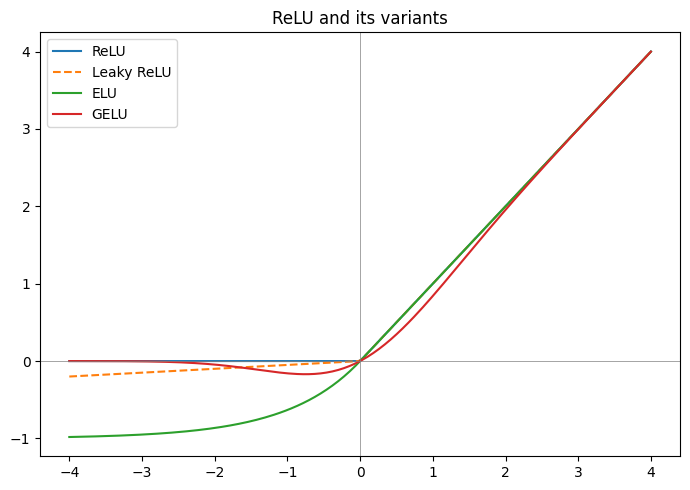

In [14]:
# Plot ReLU and its variants (mirrors Figure 6)
x = np.linspace(-4, 4, 200)

def leaky_relu(x, alpha=0.05):
    """Leaky ReLU (§5.3): like ReLU, but negative inputs get a small non-zero
    slope instead of being zeroed -- prevents the dying-ReLU problem (§5.4).

    Parameters
    ----------
    x : float or np.ndarray
        Pre-activation input value(s).
    alpha : float, default 0.05
        Slope applied to negative inputs. The reading cites a typical range of
        0.01-0.1; larger alpha keeps more gradient signal but shifts the function
        further from standard ReLU's behavior.
    """
    return np.where(x > 0, x, alpha * x)

def elu(x, alpha=1.0):
    """ELU (Exponential Linear Unit, §5.3): smooth exponential curve for negative
    inputs instead of Leaky ReLU's straight line -- can improve training dynamics
    at the cost of an exponential evaluation per unit.

    Parameters
    ----------
    x : float or np.ndarray
        Pre-activation input value(s).
    alpha : float, default 1.0
        Scales the negative-side exponential curve; alpha=1.0 is the standard
        choice, bounding negative outputs at -alpha as x -> -infinity.
    """
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))

def gelu(x):
    """GELU (Gaussian Error Linear Unit, §5.3): weights each input by its value
    under the standard normal CDF, giving a smooth transition through zero rather
    than ReLU's sharp corner. The default activation in transformer architectures.

    Parameters
    ----------
    x : float or np.ndarray
        Pre-activation input value(s).
    """
    from scipy.stats import norm
    return x * norm.cdf(x)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x, relu(x), label="ReLU")
ax.plot(x, leaky_relu(x), label="Leaky ReLU", linestyle="--")
ax.plot(x, elu(x), label="ELU")
try:
    ax.plot(x, gelu(x), label="GELU")
except ImportError:
    pass
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.set_title("ReLU and its variants")
ax.legend()
plt.tight_layout(); plt.show()


### 5.3 ReLU variants — Leaky ReLU, ELU, GELU
**Leaky ReLU:** f(x) = x if x>0 else αx (α ≈ 0.01–0.1) — a small non-zero gradient for negative
inputs. **ELU:** a smooth exponential curve for negative inputs. **GELU:** smoother still, weighting
inputs by the Gaussian CDF — the standard choice in transformer architectures (Day 30 preview).

### 5.4 The dying ReLU problem
Because ReLU's gradient is exactly zero for negative input, a unit that consistently outputs negative
values receives zero gradient forever and stays permanently "dead." A moderate fraction of dead units
is common and rarely catastrophic in a large network; a *large* fraction is a genuine warning sign.

| Activation | Formula | Gradient for x<0 | Dying-Unit Risk |
|---|---|---|---|
| ReLU | max(0, x) | Exactly 0 | Highest |
| Leaky ReLU | x if x>0 else αx | Small, non-zero (α) | Low |
| ELU | x if x>0 else α(eˣ−1) | Small, non-zero, smooth | Low |
| GELU | x·Φ(x) (Gaussian CDF) | Small, non-zero, smooth | Low |


## 6. Building a CNN Architecture

### 6.1 The classic conv-pool-conv-pool-flatten-dense pattern
Alternating convolutional layers (+ ReLU) and pooling layers extract and progressively downsample
spatial features, followed by flattening into a vector and one or more fully-connected layers for
final classification.

### 6.2 LeNet-5 — the historical starting point
LeCun et al., 1989 (refined through the 1990s) — handwritten digit recognition, deployed commercially
for reading cheques. Predates AlexNet by over two decades, illustrating that architectural ideas often
exist well before the data/compute needed to fully exploit them.

### 6.3 AlexNet — the modern inflection
Followed LeNet-5's same fundamental template, scaled up substantially.

| Property | LeNet-5 (1989/1998) | AlexNet (2012) |
|---|---|---|
| Input size | 32×32 (greyscale) | 224×224 (RGB) |
| Depth | ~5 learnable layers | 8 learnable layers |
| Activation | Sigmoid / Tanh | ReLU (§5.2) |
| Parameters | ~60,000 | ~60 million |
| Training data | Thousands of digit images | 1.2 million ImageNet images |
| Hardware | CPU | Multiple GPUs |

### 6.4 Channel depth increases while spatial dimensions decrease
As data flows through the network, spatial dimensions shrink at each pooling stage while channel
depth grows at each convolutional stage — early layers detect few, simple feature types (edges,
colors); later layers detect many, increasingly complex, specific feature types (object parts, whole
objects). This hierarchy is directly visualized in §9.


> **Audit note:** the original draft of `SimpleCNN` below implemented only two FC layers
> (`400→120`, `120→num_classes`), skipping the 84-unit hidden layer that both Figure 7 (this
> section) and the "total parameter count" worked example (§6.4, just below) assume. That made
> the class and its own worked example describe two different networks. Fixed here by adding the
> missing `Linear(120, 84)` + `ReLU` stage, so the model now matches Figure 7 exactly and the
> worked example's 62,006-parameter total is the *actual* model's parameter count — checked with
> an assertion in the cell below rather than left as an unverified claim.


In [15]:
import torch.nn as nn

# A LeNet-style CNN, matching the reading's Figure 7 architecture exactly:
# Input -> Conv+ReLU -> Pool -> Conv+ReLU -> Pool -> Flatten -> FC+ReLU(120)
#       -> FC+ReLU(84) -> Output(num_classes)
# (See the "Audit Note" markdown cell above §6.1 for why the 84-unit layer
# was added -- it was missing in the original draft, which made this class
# inconsistent with the very worked example that follows it.)
class SimpleCNN(nn.Module):
    """LeNet-5-style convolutional network (§6.1-6.2), for 3-channel 32x32 inputs.

    Parameters
    ----------
    num_classes : int, default 10
        Size of the final output layer -- one score per class, fed to a softmax
        (implicitly, via nn.CrossEntropyLoss, §7.2) at training time.
    """

    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # nn.Conv2d(in_channels, out_channels, kernel_size):
            #   in_channels=3 matches the RGB input; out_channels=6 is the number
            #   of learned filters (=> 6 output channels, §3.4); kernel_size=5
            #   is the filter's spatial extent (§2). stride and padding default
            #   to 1 and 0 (i.e. "valid" convolution, §3.2) since they're omitted.
            nn.Conv2d(3, 6, kernel_size=5),   # §2-3: learnable kernel
            nn.ReLU(),                         # §5.2: non-linearity, no parameters
            # nn.MaxPool2d(kernel_size, stride): kernel_size=2 pools 2x2 windows;
            # stride=2 makes them non-overlapping, halving each spatial dimension.
            nn.MaxPool2d(2, stride=2),         # §4.1: downsampling
            nn.Conv2d(6, 16, kernel_size=5),   # in_channels=6 matches Conv1's output; 16 filters
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                      # §6.1: reshapes (16,5,5) -> a length-400 vector
            # nn.Linear(in_features, out_features): a fully-connected layer with
            # in_features*out_features + out_features learnable parameters (§6.4
            # worked example). in_features here must equal the flattened size.
            nn.Linear(16 * 5 * 5, 120),        # FC1, per Figure 7
            nn.ReLU(),
            # nn.Dropout(p): p is the probability of zeroing each unit during
            # training (§8.2). p=0.5 is a common, fairly strong default; p is
            # ignored at inference time once the module is switched to .eval().
            nn.Dropout(0.5),                   # §8.2: regularization
            nn.Linear(120, 84),                # FC2, per Figure 7 (previously missing)
            nn.ReLU(),
            nn.Linear(84, num_classes),        # FC3, per Figure 7 -- raw class scores (logits)
        )

    def forward(self, x):
        """Run the forward pass.

        Parameters
        ----------
        x : torch.Tensor, shape (batch_size, 3, 32, 32)
            A batch of RGB images.

        Returns
        -------
        torch.Tensor, shape (batch_size, num_classes)
            Raw class scores (logits) -- not yet passed through softmax; use with
            nn.CrossEntropyLoss (§7.2), which applies softmax internally.
        """
        x = self.features(x)
        return self.classifier(x)

model = SimpleCNN(num_classes=10)
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal learnable parameters: {total_params:,}")
print("Expected from the worked example below: 62,006")
assert total_params == 62_006, f"Mismatch: got {total_params}, expected 62,006"
print("Assertion passed: model's actual parameter count matches the worked example exactly.")


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=400, out_features=120, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=120, out_features=84, bias=True)
    (5): ReLU()
    (6): Linear(in_features=84, out_features=10, bias=True)
  )
)

Total learnable parameters: 62,006
Expected from the worked example below: 62,006
Assertion passed: model's actual parameter count matches the worked example exactly.


### Worked Example: total parameter count for a complete small CNN
Using the reading's Figure 7 architecture: Conv1 (5×5×3×6 + 6 bias) = 456; Conv2 (5×5×6×16 + 16 bias)
= 2,416; FC1 (400×120 + 120) = 48,120; FC2 (120×84 + 84) = 10,164; FC3 (84×10 + 10) = 850.
**Total: 62,006 parameters** — the fully-connected layers account for ~95% of this small network's
total parameters, directly explaining why GAP's dramatic reduction (§4.3) matters so much in modern
architectures.


In [16]:
# Verify the layer-by-layer parameter breakdown against the reading's worked example
def fc_params_count(n_in, n_out):
    """Count a fully-connected (Linear) layer's learnable parameters (§6.4).

    Parameters
    ----------
    n_in : int
        Number of input features (e.g. the flattened conv output, or the
        previous FC layer's output size).
    n_out : int
        Number of output units in this layer.

    Returns
    -------
    int
        n_in * n_out weights, plus n_out biases (one bias per output unit).
    """
    return n_in * n_out + n_out

conv1 = conv_params_count(5, 5, 3, 6)
conv2 = conv_params_count(5, 5, 6, 16)
fc1 = fc_params_count(400, 120)
fc2 = fc_params_count(120, 84)
fc3 = fc_params_count(84, 10)

breakdown = {"Conv1": conv1, "Conv2": conv2, "FC1": fc1, "FC2": fc2, "FC3": fc3}
for name, count in breakdown.items():
    print(f"{name}: {count:,}")
total = sum(breakdown.values())
fc_total = fc1 + fc2 + fc3
print(f"\nTotal: {total:,} parameters")
print(f"Fully-connected share: {fc_total:,} / {total:,} = {fc_total/total:.1%}")


Conv1: 456
Conv2: 2,416
FC1: 48,120
FC2: 10,164
FC3: 850

Total: 62,006 parameters
Fully-connected share: 59,134 / 62,006 = 95.4%


### 6.5 A forward reference to Day 30
Day 30 surveys how this template evolved: VGG's systematic use of small, stacked 3×3 kernels; ResNet's
residual connections (developed to overcome the vanishing gradient problem, §5.2); and efficient,
mobile-friendly architectures. Everything in this day is the necessary foundation.


## 7. Training a CNN

### 7.1 Backpropagation through convolutional layers
Backpropagation computes the gradient of the loss with respect to every learnable parameter, working
backward from the output via the chain rule. Because a convolutional layer's weights are *shared*
across every spatial position (§2.4), the gradient for a single kernel weight must be **accumulated
across every position where it was used** — a rich, well-averaged gradient signal from an entire
feature map, not just a single spatial position.

### 7.2 Loss functions for classification — cross-entropy
Cross-entropy loss = **−log(predicted probability of the true class)**. Small loss for confident
correct predictions; rapidly growing loss for confident incorrect predictions.


In [17]:
# Worked Example: computing cross-entropy loss for a single prediction (mirrors the reading's example)
def cross_entropy_single(predicted_probs, true_class_idx):
    """Cross-entropy loss for one prediction against one true label (§7.2).

    Parameters
    ----------
    predicted_probs : sequence of float
        The model's predicted probability for each class (must sum to ~1, e.g.
        the output of a softmax).
    true_class_idx : int
        Index of the correct class.

    Returns
    -------
    float
        -log(predicted_probs[true_class_idx]). Small when the correct class was
        given high probability; large (diverging toward infinity) as the
        predicted probability for the correct class approaches 0.
    """
    return -np.log(predicted_probs[true_class_idx])

probs_good = [0.7, 0.2, 0.1]
probs_bad = [0.1, 0.7, 0.2]
true_class = 0

print(f"Prediction {probs_good}, true class {true_class}: loss = {cross_entropy_single(probs_good, true_class):.3f}")
print(f"Prediction {probs_bad}, true class {true_class}:  loss = {cross_entropy_single(probs_bad, true_class):.3f}")

# Cross-check against PyTorch's implementation.
# nn.CrossEntropyLoss(logits, labels): logits are RAW (pre-softmax) class scores,
# shape (batch, num_classes); labels are integer class indices, shape (batch,).
# The loss applies log-softmax internally, so we feed log(probs) as a stand-in
# for logits here (log-softmax of log(p) recovers p, since our p already sums to 1).
logits = torch.log(torch.tensor([probs_good, probs_bad]))  # convert probs to "logits" for demo purposes
labels = torch.tensor([true_class, true_class])
loss_fn = nn.CrossEntropyLoss()
print("\nPyTorch cross-entropy (on log-probs as logits):", loss_fn(logits, labels).item())


Prediction [0.7, 0.2, 0.1], true class 0: loss = 0.357
Prediction [0.1, 0.7, 0.2], true class 0:  loss = 2.303

PyTorch cross-entropy (on log-probs as logits): 1.3296300172805786


### 7.3 Optimizers — SGD with momentum and Adam
**SGD:** `weight ← weight − (learning_rate × gradient)`. **SGD + momentum** accumulates a running
average of past gradients, smoothing noisy estimates and building speed in consistent directions.
**Adam** maintains a separate, adaptively-scaled learning rate per parameter — the default choice for
most modern training.

| Optimizer | Per-Parameter Adaptive Rate? | Typical Convergence Speed | Common Use |
|---|---|---|---|
| SGD (plain) | No | Slow, but often best final result | Long, carefully-tuned training runs |
| SGD + Momentum | No | Faster than plain SGD | A strong, widely-used default |
| Adam | Yes | Fast, especially early in training | Default choice for most modern training |

### 7.4 Learning rate scheduling
The learning rate is widely regarded as the single most consequential hyperparameter. Too high →
divergence/oscillation; too low → extremely slow convergence. **Learning rate scheduling**
(step decay, cosine annealing) reduces it systematically over training.


In [18]:
# Full training loop skeleton, mirroring Figure 8: forward pass -> loss -> backprop -> optimizer step
model = SimpleCNN(num_classes=10)
criterion = nn.CrossEntropyLoss()                                  # §7.2: no tunable params here
# optim.Adam(params, lr): params is the iterable of tensors to optimize (always
# model.parameters()); lr (learning rate) scales each weight update -- §7.4 calls
# this "the single most consequential hyperparameter." 1e-3 is Adam's common default.
optimizer = optim.Adam(model.parameters(), lr=1e-3)                # §7.3
# CosineAnnealingLR(optimizer, T_max): wraps an optimizer and decays its lr
# following a cosine curve down to (near) zero over T_max scheduler.step() calls
# -- T_max=50 means one full cosine cycle across 50 epochs (§7.4).
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)  # §7.4

# Synthetic data standing in for a real DataLoader, so this cell is runnable standalone
fake_images = torch.randn(8, 3, 32, 32)
fake_labels = torch.randint(0, 10, (8,))

for epoch in range(3):  # shortened for demonstration; the reading's example uses 50
    optimizer.zero_grad()                      # clear gradients from the previous step
    outputs = model(fake_images)              # forward pass (Figure 8)
    loss = criterion(outputs, fake_labels)     # compute loss
    loss.backward()                            # backpropagation (§7.1): populates .grad on every parameter
    optimizer.step()                           # weight update: applies Adam's rule using those gradients
    scheduler.step()                           # advance the cosine schedule by one epoch
    print(f"Epoch {epoch+1}: loss = {loss.item():.4f}, lr = {scheduler.get_last_lr()[0]:.6f}")


Epoch 1: loss = 2.3408, lr = 0.000999
Epoch 2: loss = 2.3189, lr = 0.000996
Epoch 3: loss = 2.3159, lr = 0.000991


### 7.5 Transfer learning and fine-tuning — a direct practical link
Rather than training from randomly initialized weights, practitioners overwhelmingly start from a
pretrained network and fine-tune it — exactly the approach Day 26's PP12 project uses: a pretrained
MobileNetV2/ResNet backbone, fine-tuned for mask classification, run for comparatively few epochs at a
comparatively low learning rate, since pretrained weights already encode broadly useful features.


## 8. Regularization in CNNs

### 8.1 Overfitting in the CNN context
A network fits the specific training examples (including noise) rather than the general underlying
pattern — high training accuracy, poor validation/test accuracy. CNNs, with potentially very large
parameter counts, are genuinely susceptible, especially with limited labeled data relative to network
capacity.

### 8.2 Dropout
During training, a randomly selected subset of units is temporarily zeroed on each step — forcing the
network to avoid over-relying on any single unit, encouraging robust, distributed representations.
Applied **only during training**; at inference time all units remain active. Forgetting to switch to
evaluation mode (`model.eval()` in PyTorch) is a genuine, common bug producing inconsistent predictions.


In [19]:
# Demonstrate dropout's train vs. eval mode behavior directly
# nn.Dropout(p): p is the probability that each unit is zeroed on a given forward
# pass during training (§8.2). p=0.5 means, on average, half of `sample_input`'s
# ten entries will be zeroed each time the layer is called in .train() mode.
dropout_layer = nn.Dropout(p=0.5)
sample_input = torch.ones(10)

dropout_layer.train()
print("Training mode (dropout active):", dropout_layer(sample_input))

dropout_layer.eval()
print("Eval mode (dropout disabled):  ", dropout_layer(sample_input))


Training mode (dropout active): tensor([0., 2., 2., 0., 2., 2., 0., 2., 2., 2.])
Eval mode (dropout disabled):   tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])


### 8.3 Batch normalization
Inserted within the network (typically after a conv layer, before its activation), normalizing each
mini-batch's activations to zero mean / unit variance, followed by a learned scale and shift. Primary
benefit: **training stability** — reduces sensitivity to weight initialization and learning rate,
often allowing higher learning rates and faster convergence. Behaves differently at inference time:
uses a running average of mean/variance accumulated during training rather than the current batch's
statistics — another reason `model.eval()` matters.


In [20]:
# Demonstrate batch normalization's train vs. eval behavior
# nn.BatchNorm1d(num_features): num_features must match the size of the feature
# dimension being normalized (here, 4 -- the second dimension of `batch_train`,
# shape (batch, 4)). BN learns one scale and one shift parameter per feature (§8.3).
bn_layer = nn.BatchNorm1d(num_features=4)
batch_train = torch.randn(16, 4) * 5 + 3  # arbitrary mean/scale

bn_layer.train()
out_train = bn_layer(batch_train)
print("Training mode output mean/std per feature:", out_train.mean(dim=0).detach().numpy().round(3), out_train.std(dim=0).detach().numpy().round(3))

bn_layer.eval()
out_eval = bn_layer(batch_train)  # uses running stats accumulated during the (single) training step above
print("Eval mode uses running statistics accumulated during training, not this batch's own stats.")


Training mode output mean/std per feature: [-0.  0.  0. -0.] [1.033 1.033 1.033 1.033]
Eval mode uses running statistics accumulated during training, not this batch's own stats.


### 8.4 Weight decay
Adds a penalty term to the loss proportional to the sum of squared weights (L2 regularization),
encouraging smaller weights unless a larger value is genuinely justified — large weights are a
signature of overfitting to training-data noise.

### 8.5 Data augmentation as regularization — a direct callback to Day 27
By ensuring the network never sees identical pixel values twice, augmentation directly discourages
memorization — the same "encourage robustness, discourage memorization" logic as every other
regularization technique, just implemented at the input-data level.

| Technique | Where Applied | What It Discourages |
|---|---|---|
| Dropout (§8.2) | Inside the network (layer activations) | Over-reliance on any single unit |
| Batch normalization (§8.3) | Inside the network (layer activations) | Sensitivity to activation-scale drift |
| Weight decay (§8.4) | The loss function | Unnecessarily large weight values |
| Data augmentation (§8.5) | The input data | Memorization of exact training pixel values |


In [21]:
# Weight decay demonstrated via the optimizer's weight_decay parameter (L2 regularization)
# optim.Adam(..., weight_decay): weight_decay scales an L2 penalty added to the
# loss for every parameter (§8.4) -- larger values push weights toward smaller
# magnitudes more aggressively. 1e-4 is a common, fairly mild default; 0 (Adam's
# own default) disables weight decay entirely.
optimizer_with_decay = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
print("Optimizer configured with weight_decay=1e-4 (L2 penalty on all weights):")
print(optimizer_with_decay)


Optimizer configured with weight_decay=1e-4 (L2 penalty on all weights):
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


## 9. Visualizing & Interpreting CNNs

### 9.1 Visualizing learned filters
Because a trained kernel is mechanically identical to a hand-designed filter (§2.5), it can be directly
inspected the same way. Early-layer filters in a trained CNN overwhelmingly resemble simple, classical
edge and color-blob detectors — discovered entirely through gradient descent, with no explicit
instruction to detect edges. This echoes both Sobel-style hand-designed kernels *and* biological V1
simple cells (Day 26 §3) — three independently-derived processes converging on a similar answer.


First conv layer weight shape: torch.Size([6, 3, 5, 5])


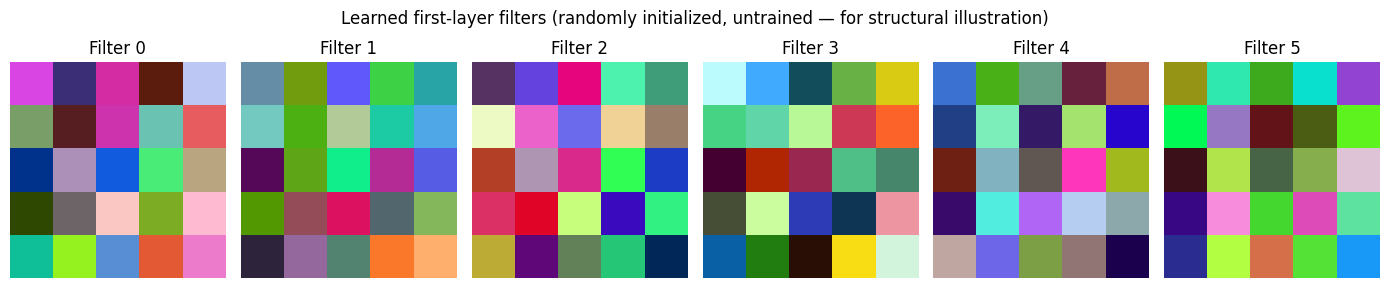


Note: since this model is untrained, these filters are still random noise.
In a genuinely trained network, these would converge toward edge/color-blob detectors (§9.1).


In [22]:
# Visualize the actual learned first-layer filters of the SimpleCNN model built above
first_conv_weights = model.features[0].weight.detach()  # shape: (6, 3, 5, 5)
print("First conv layer weight shape:", first_conv_weights.shape)

fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for i, ax in enumerate(axes):
    filt = first_conv_weights[i].permute(1, 2, 0).numpy()
    filt_normalized = (filt - filt.min()) / (filt.max() - filt.min() + 1e-8)
    ax.imshow(filt_normalized)
    ax.set_title(f"Filter {i}")
    ax.axis("off")
plt.suptitle("Learned first-layer filters (randomly initialized, untrained — for structural illustration)")
plt.tight_layout(); plt.show()
print("\nNote: since this model is untrained, these filters are still random noise.")
print("In a genuinely trained network, these would converge toward edge/color-blob detectors (§9.1).")


### 9.2 Feature map visualization
Visualizing a trained network's *feature maps* (the output at a specific layer for a specific image)
reveals what the network actually detected in that image — early layers highlight edges/textures;
deeper layers activate more selectively for larger, semantically meaningful structures.


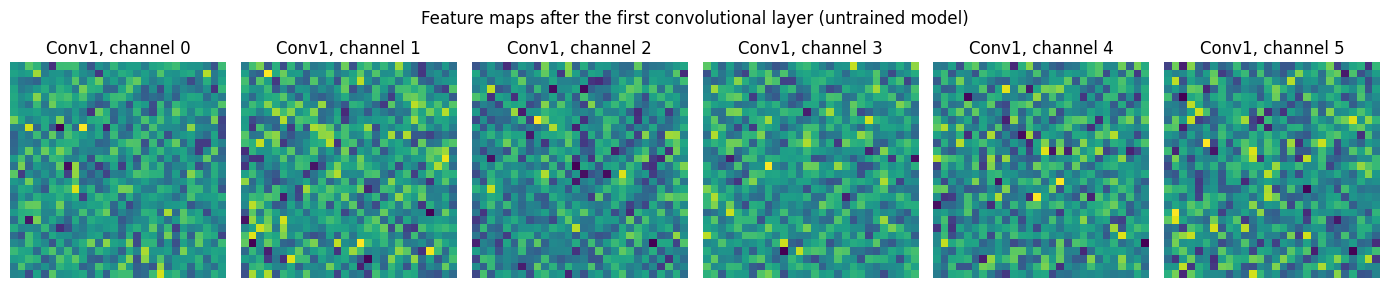

In [23]:
# Extract and visualize feature maps at each stage of the forward pass, for one input image
sample_image = torch.randn(1, 3, 32, 32)

activations = {}
def get_activation(name):
    """Build a forward hook that stores a layer's output activations by name (§9.2).

    Parameters
    ----------
    name : str
        Key under which this layer's output will be stored in the enclosing
        `activations` dict -- lets multiple layers be hooked and later
        distinguished by name.

    Returns
    -------
    callable
        A hook function with PyTorch's required (module, input, output) signature,
        suitable for `layer.register_forward_hook(...)`.
    """
    def hook(model, input, output):
        """PyTorch forward-hook callback (signature fixed by PyTorch's API).

        Parameters
        ----------
        model : nn.Module
            The specific layer this hook is attached to (not the whole SimpleCNN).
        input : tuple of torch.Tensor
            That layer's input tensor(s), unused here.
        output : torch.Tensor
            That layer's output -- the activations we want to capture.
        """
        activations[name] = output.detach()
    return hook

model.features[0].register_forward_hook(get_activation("conv1"))
model.features[3].register_forward_hook(get_activation("conv2"))

_ = model(sample_image)

fig, axes = plt.subplots(1, 6, figsize=(14, 3))
conv1_maps = activations["conv1"][0]  # shape: (6, H, W)
for i, ax in enumerate(axes):
    ax.imshow(conv1_maps[i].numpy(), cmap="viridis")
    ax.set_title(f"Conv1, channel {i}")
    ax.axis("off")
plt.suptitle("Feature maps after the first convolutional layer (untrained model)")
plt.tight_layout(); plt.show()


### 9.3 Class Activation Mapping — Grad-CAM
Grad-CAM computes the gradient of a target class's predicted score with respect to a chosen
convolutional layer's feature maps (typically the last conv layer), uses these gradients to weight
each channel by its importance, and combines the weighted maps into a coarse localization heatmap —
a genuine debugging and trust-building tool (e.g., catching a model that learned "snow present" instead
of "wolf" due to spurious background correlation in training data).

**Limitation:** Grad-CAM's heatmap resolution is limited by the chosen layer's spatial resolution
(often as small as 7×7 for a 224×224 input) — a coarse approximation, not a pixel-precise segmentation.


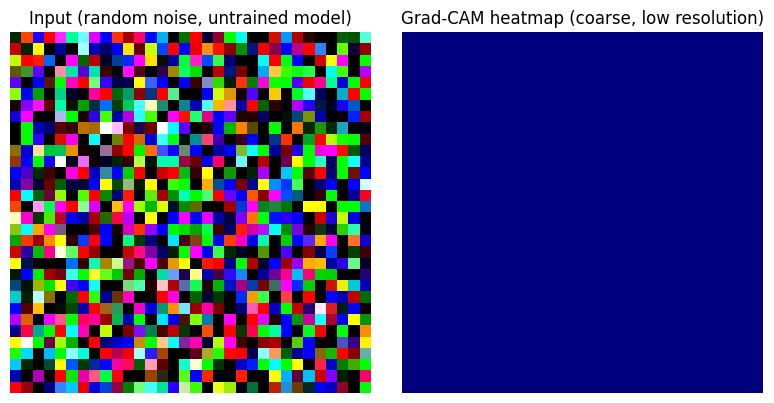

Heatmap spatial resolution: (10, 10) — coarse, matching §9.3's stated limitation


In [24]:
# A minimal from-scratch Grad-CAM implementation, applied to the SimpleCNN model
def grad_cam(model, input_tensor, target_class, target_layer):
    """Compute a Grad-CAM localization heatmap (§9.3).

    Parameters
    ----------
    model : nn.Module
        The trained (or, here, untrained) classifier to explain.
    input_tensor : torch.Tensor, shape (1, C, H, W)
        A single input image (batch size 1).
    target_class : int
        Index of the class whose prediction we want to explain -- Grad-CAM
        answers "which pixels drove the score for *this* class."
    target_layer : nn.Module
        The convolutional layer whose activations/gradients are used to build
        the heatmap. §9.3 recommends the *last* convolutional layer: deep enough
        to encode class-discriminative features, shallow enough to still retain
        meaningful spatial structure (as opposed to a fully-connected layer,
        which has none).

    Returns
    -------
    np.ndarray, shape (h, w)
        A coarse heatmap (spatial size of target_layer's output, e.g. 5x5 for
        this model) normalized to [0, 1], where higher values indicate regions
        that contributed more to the target class's score.
    """
    activations = {}
    gradients = {}

    def forward_hook(module, input, output):
        """PyTorch forward-hook callback: stashes target_layer's activations
        (output) for later use in the CAM weighting step below."""
        activations["value"] = output

    def backward_hook(module, grad_input, grad_output):
        """PyTorch full-backward-hook callback: stashes the gradient of the
        target class's score w.r.t. target_layer's output.

        Parameters
        ----------
        grad_output : tuple of torch.Tensor
            grad_output[0] is the gradient we want; the tuple form is a fixed
            part of PyTorch's hook API (a layer can have multiple outputs).
        """
        gradients["value"] = grad_output[0]

    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_full_backward_hook(backward_hook)

    model.zero_grad()
    output = model(input_tensor)
    score = output[0, target_class]
    score.backward()

    handle_f.remove()
    handle_b.remove()

    weights = gradients["value"].mean(dim=(2, 3), keepdim=True)  # global-average the gradients per channel
    cam = torch.relu((weights * activations["value"]).sum(dim=1)).squeeze()
    cam = cam / (cam.max() + 1e-8)
    return cam.detach().numpy()

target_layer = model.features[3]  # last conv layer (§9.3: "typically the last convolutional layer")
heatmap = grad_cam(model, sample_image, target_class=0, target_layer=target_layer)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sample_image[0].permute(1, 2, 0).numpy())
axes[0].set_title("Input (random noise, untrained model)")
axes[1].imshow(heatmap, cmap="jet")
axes[1].set_title("Grad-CAM heatmap (coarse, low resolution)")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()
print(f"Heatmap spatial resolution: {heatmap.shape} — coarse, matching §9.3's stated limitation")


### 9.4–9.5 Forward reference and practical guidance
Grad-CAM's interpretability role becomes centrally important (not just a nice-to-have) in Day 37's
medical imaging content, where understanding *why* a model made a diagnostic prediction is often a
clinical/regulatory requirement.

**Practical checklist:**
- Kernel visualization (§9.1) — focus on the first 1–2 conv layers only; deeper kernels operate on
  already-abstracted feature maps and become uninterpretable as raw image patches.
- Feature map visualization (§9.2) — compare the same layer across several different input images,
  not just one, to distinguish a genuinely meaningful feature from an incidental one-image pattern.
- Grad-CAM (§9.3) — always generate heatmaps for both correctly *and* incorrectly classified examples;
  failures are often more diagnostically informative than successes.

| Technique | Best Applied To | Primary Question It Answers |
|---|---|---|
| Kernel visualization (§9.1) | First 1–2 convolutional layers only | "What basic patterns is this layer built to detect?" |
| Feature map visualization (§9.2) | Any layer, for a specific input image | "What did this layer actually detect in THIS image?" |
| Grad-CAM (§9.3) | Late convolutional layers, for a specific class | "Which region drove the prediction for THIS class?" |


## 10. Research Frontiers

### 10.1 The shift toward Vision Transformers
A ViT processes an image as a sequence of patches, using attention to let every patch directly
consider every other patch's content — a departure from the strictly local, hierarchically-growing
receptive field structure CNNs build (§3.3). Full treatment begins in Day 30.

### 10.2 Hybrid CNN-Transformer architectures
Combine convolution's strong local inductive bias and computational efficiency (early stages) with
attention's ability to model long-range, global relationships (later stages). A CNN's locality
assumption is genuinely correct for most natural images and is a large part of why CNNs train
effectively on modest labeled data; a ViT's attention imposes no such assumption, granting flexibility
but requiring far more training data.

### 10.3 Efficient and mobile CNN design
MobileNet and EfficientNet use **depthwise separable convolutions** — factoring a standard
multi-channel convolution into a per-channel spatial convolution followed by a 1×1 channel-mixing
convolution — dramatically reducing parameter count and compute.


In [25]:
# Worked Example: depthwise separable convolution cost comparison (mirrors the reading's worked example)
def standard_conv_ops(kernel_size, c_in, c_out):
    """Multiply-accumulate operations for one spatial position of a standard
    convolution (§3.4, §10.3).

    Parameters
    ----------
    kernel_size : int
        Spatial size of the (square) kernel.
    c_in : int
        Input channel count -- every filter spans the full input depth.
    c_out : int
        Number of filters == output channel count.

    Returns
    -------
    int
        kernel_size^2 * c_in * c_out operations per spatial position.
    """
    return kernel_size * kernel_size * c_in * c_out

def depthwise_separable_ops(kernel_size, c_in, c_out):
    """Multiply-accumulate operations for one spatial position of a depthwise
    separable convolution (§10.3): a per-channel spatial (depthwise) stage
    followed by a 1x1 channel-mixing (pointwise) stage.

    Parameters
    ----------
    kernel_size : int
        Spatial size of the depthwise stage's per-channel kernel.
    c_in : int
        Input channel count.
    c_out : int
        Output channel count (produced by the pointwise 1x1 stage).

    Returns
    -------
    int
        Combined depthwise + pointwise operations per spatial position --
        typically far fewer than an equivalent standard_conv_ops(...) call.
    """
    depthwise = kernel_size * kernel_size * c_in          # one small spatial kernel per input channel
    pointwise = 1 * 1 * c_in * c_out                       # 1x1 channel-mixing convolution
    return depthwise + pointwise

standard = standard_conv_ops(3, 64, 128)
separable = depthwise_separable_ops(3, 64, 128)

print(f"Standard 3x3 convolution (64 -> 128 channels): {standard:,} multiply-accumulate ops per position")
print(f"Depthwise separable convolution (same transform): {separable:,} ops per position")
print(f"Reduction factor: ~{standard / separable:.1f}x fewer operations")


Standard 3x3 convolution (64 -> 128 channels): 73,728 multiply-accumulate ops per position
Depthwise separable convolution (same transform): 8,768 ops per position
Reduction factor: ~8.4x fewer operations


### 10.4 Self-supervised CNN pretraining
Defines a training objective requiring no human-provided labels — predicting a missing/transformed
portion of an image, or (as in DINO) learning representations consistent across augmented views of the
same image, directly repurposing Day 27 §6's augmentation techniques as the training signal itself.
Particularly valuable in domains (medical imaging chief among them) where labeled data is scarce but
unlabeled data is abundant.

### 10.5 Closing perspective
Every concept a modern CNN architecture is built from — convolution (§2), layer mechanics (§3),
pooling (§4), non-linearity (§5), the classic architectural template (§6), training (§7),
regularization (§8), and interpretability (§9) — has now been developed from first principles. Day 30
assumes fluent command of every one of these building blocks and surveys how the field scaled this
template into today's much deeper backbone architectures: LeNet and AlexNet through VGG, ResNet, and
beyond.


## 11. Common Pitfalls: A Practical Debugging Checklist

Because a CNN combines many interacting components — architecture (§2–6), training dynamics (§7), and
regularization (§8) — a poorly performing network can have its root cause in any of several places.
In order:

1. **Check for a shape mismatch before assuming a training-dynamics problem** — per §3.3's
   output-size formula, an incorrectly computed flatten dimension is one of the most common errors
   when building a network by hand, and produces an immediate, unambiguous error — fix this first.
2. **Plot training AND validation loss together, not just accuracy** — per §8.1, a widening gap
   between training and validation loss is the clearest direct signal of overfitting, visible before
   it shows up as a validation-accuracy plateau.
3. **If loss is not decreasing at all, suspect the learning rate first** — per §7.4, too-high causes
   visible divergence/oscillation; too-low produces a nearly-flat curve easily mistaken for a bug.
4. **Confirm dropout and batch normalization are correctly switched to evaluation mode at inference
   time** — per §8.2's note on this exact bug (`model.eval()` in PyTorch); forgetting it produces
   inconsistent, non-reproducible predictions.
5. **If a network trains well but performs poorly on genuinely new data, check for a
   spurious-correlation shortcut** — per §9.3's wolves-vs-huskies example, Grad-CAM on a handful of
   correctly and incorrectly classified examples often reveals this directly.
6. **Verify preprocessing consistency between training and inference** — Day 27 §1.2/§5.2's concern,
   not CNN-specific, but worth re-checking here.

### 11.1 A note on reproducibility
Training involves several sources of randomness: random weight initialization, dropout's random unit
selection (§8.2), and data augmentation's random transformations (§8.5) all introduce run-to-run
variation. For any comparison between two training configurations, fix all relevant random seeds and,
ideally, average results across a small number of independent runs.


In [26]:
# Demonstrate the shape-mismatch pitfall directly, and how the output-size formula catches it in advance
input_size = 32
conv1_out = conv_output_size(input_size, kernel_size=5, stride=1, padding=0)
pool1_out = conv1_out // 2
conv2_out = conv_output_size(pool1_out, kernel_size=5, stride=1, padding=0)
pool2_out = conv2_out // 2

print(f"Input: {input_size}x{input_size}")
print(f"After Conv1 (5x5, valid): {conv1_out}x{conv1_out}")
print(f"After Pool1 (2x2, stride 2): {pool1_out}x{pool1_out}")
print(f"After Conv2 (5x5, valid): {conv2_out}x{conv2_out}")
print(f"After Pool2 (2x2, stride 2): {pool2_out}x{pool2_out}")

expected_flatten_dim = pool2_out * pool2_out * 16  # 16 output channels from Conv2
print(f"\nCorrect flatten dimension for nn.Linear: {pool2_out}*{pool2_out}*16 = {expected_flatten_dim}")
print("(This matches the SimpleCNN architecture's nn.Linear(16 * 5 * 5, 120) above.)")


Input: 32x32
After Conv1 (5x5, valid): 28x28
After Pool1 (2x2, stride 2): 14x14
After Conv2 (5x5, valid): 10x10
After Pool2 (2x2, stride 2): 5x5

Correct flatten dimension for nn.Linear: 5*5*16 = 400
(This matches the SimpleCNN architecture's nn.Linear(16 * 5 * 5, 120) above.)


## Glossary of Terms

| Term | Definition |
|---|---|
| Kernel / Filter | A small matrix of learnable weights slid across an input to compute a feature map (§2.1, §2.3) |
| Feature map | The output produced by applying a kernel across an input (§2.1) |
| Stride | How many positions a kernel moves between successive applications (§3.1) |
| Padding | A border added around an input to control output size (§3.2) |
| Receptive field | The region of the original input a given unit is sensitive to (§3.3) |
| 1×1 convolution | A kernel with no spatial extent, used for channel mixing (§3.4) |
| Max / average pooling | Downsampling operations summarizing a local region by its max or mean (§4.1) |
| Global average pooling (GAP) | Averaging an entire feature map to one value per channel (§4.3) |
| ReLU | max(0, x); the dominant CNN activation function (§5.2) |
| Vanishing gradient | Gradients shrinking toward zero as they propagate through saturated layers (§5.2) |
| Backpropagation | The algorithm computing each parameter's gradient via the chain rule (§7.1) |
| Cross-entropy loss | The standard loss function for classification (§7.2) |
| Dropout | Randomly zeroing units during training to discourage co-dependence (§8.2) |
| Batch normalization | Normalizing layer activations per mini-batch during training (§8.3) |
| Grad-CAM | A technique visualizing which image regions drove a prediction (§9.3) |

---
## Chapter Summary: Key Takeaways

- A convolutional kernel is mechanically identical to a classical filter (§2.5) — the only difference
  is that its weights are learned via gradient descent rather than hand-designed.
- Local receptive fields and weight sharing (§2.4) give convolutions a roughly 2,000× parameter
  advantage over a comparable fully-connected layer, making training on realistic dataset sizes
  tractable at all.
- Stride, padding, and kernel size together determine output size (§3.3) via a formula worth applying
  directly; receptive field grows with network depth, not kernel size alone.
- Non-linearity between layers is what allows depth to matter (§5.1) — stacked linear operations
  collapse into a single equivalent linear operation without it.
- ReLU dominates because it avoids the saturation that causes vanishing gradients (§5.2) — directly
  setting up Day 30's residual-connection solution to the same underlying problem at greater depth.
- Training is backpropagation + an optimizer, applied repeatedly (§7) — and transfer learning (§7.5)
  is this same training loop, just initialized from pretrained weights rather than random ones.
- Dropout, batch normalization, weight decay, and data augmentation (§8) all combat overfitting via
  the same underlying logic — discourage memorization, encourage robust, distributed representations
  — implemented at different points in the pipeline.
- Grad-CAM makes CNN decisions inspectable (§9.3) — a genuine debugging tool, not just a curiosity,
  and the direct technical foundation for Day 37's medical imaging explainability content.

---
**End of Day 29 notebook.** *(Theory-consolidation day — no assigned practical project brief, per the
source document.)*
